# Data-to-Data Flow Matching – FashionMNIST (Unconditional)

## Motivation / Overview

This notebook transfers the Data-to-Data Flow Matching approach from Notebook 04 to **FashionMNIST** -> now **without class conditioning**.

In Notebook 04 the model was trained on multiple class pairs and received the source/target class as an explicit conditioning signal. Here, that signal is removed entirely: the model must learn the transport between two distributions purely from the data pairs, with no label information.

The chosen classes are:

- **Source:** Sneaker (class 7)
- **Target:** Ankle Boot (class 9)

Both classes are footwear with a similar overall shape but distinct structure. The transition is visually non-trivial -> a sneaker features a flat sole with lacing, while an ankle boot has an elevated shaft and a clearly different silhouette.

## Objective

A Rectified Flow model is trained using the Data-to-Data Flow Matching objective:

$$
x_A \sim p_{\text{Sneaker}}, \quad x_B \sim p_{\text{Ankle Boot}}
$$

The model receives **no** conditioning signal. Meaning, it learns the transport path between the two distributions purely from the image pairs.

The interpolation path is defined as:

$$
z_t = (1-t)\,x_A + t\,x_B, \quad t \in [0,1]
$$

The target velocity is:

$$
u_t = x_B - x_A
$$

The model approximates:

$$
v_\theta(z_t, t) \approx x_B - x_A
$$

### Key Questions

- Does the model learn a structured transport despite the absence of conditioning?
- Are the intermediate states semantically coherent?
- How does the learned flow compare to simple linear interpolation?

In [6]:
import os
import random
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms

# Fix random seeds for reproducibility across runs
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

# Use GPU when available; fall back to CPU otherwise
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Detect whether we are running inside Google Colab
IN_COLAB = "google.colab" in sys.modules


def find_repo_root():
    """Locate the minRF_interpolation repository root.

    Checks multiple candidate paths to support both local VS Code
    and Google Colab environments without manual path configuration.
    Returns the first path that contains 'dit.py', or None if not found.
    """
    candidates = []

    # 1) Respect an explicit user override via environment variable
    env_repo = os.environ.get("MINRF_REPO")
    if env_repo:
        candidates.append(Path(env_repo).expanduser())

    # 2) Check well-known fixed locations and relatives of the working dir
    cwd = Path.cwd().resolve()
    candidates.extend(
        [
            cwd,
            cwd / "minRF_interpolation",
            cwd.parent / "minRF_interpolation",
            Path("/content/minRF_interpolation"),
            Path("/content/drive/MyDrive/minRF_interpolation"),
            Path("/content/Projects/minRF_interpolation"),
            Path.home() / "Projects" / "minRF_interpolation",
            Path("/home/felicitasl/Projects/minRF_interpolation"),
        ]
    )

    # 3) Walk up the directory tree as a final fallback
    for parent in [cwd, *cwd.parents]:
        candidates.append(parent / "minRF_interpolation")

    # Deduplicate and test each candidate for the presence of dit.py
    seen = set()
    for path in candidates:
        p = path.expanduser().resolve()
        if str(p) in seen:
            continue
        seen.add(str(p))
        if (p / "dit.py").exists():
            return p

    return None


repo_path = find_repo_root()

# In Colab, clone the repository automatically if it cannot be found locally
if repo_path is None and IN_COLAB:
    repo_url = os.environ.get("MINRF_REPO_URL", "https://github.com/Felinchen76/minRF_interpolation.git")
    clone_target = Path("/content/minRF_interpolation")

    if not clone_target.exists():
        print("Repository not found locally. Cloning:", repo_url)
        subprocess.run(["git", "clone", repo_url, str(clone_target)], check=True)

    repo_path = find_repo_root()

if repo_path is None:
    raise FileNotFoundError(
        "Could not locate minRF_interpolation repository. "
        "Set environment variable MINRF_REPO, or in Colab set MINRF_REPO_URL and rerun this cell. "
        "Checked cwd=" + str(Path.cwd().resolve())
    )

print("Using repo_path:", repo_path)

# Add the repository root to sys.path so local modules are importable
if str(repo_path) not in sys.path:
    sys.path.insert(0, str(repo_path))

from dit import DiT_Llama

Using device: cuda
Using repo_path: /content/minRF_interpolation


## 1. FashionMNIST Dataset – Two Classes, No Conditioning

Only two classes are loaded:

- **Source:** Class 7 – Sneaker
- **Target:** Class 9 – Ankle Boot

No conditioning signal is used. Each training sample is a randomly drawn pair $(x_A, x_B)$ with $x_A \sim p_{\text{Sneaker}}$ and $x_B \sim p_{\text{Ankle Boot}}$.

FashionMNIST class overview:

| ID | Class |
|---|---|
| 0 | T-shirt/top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | **Sneaker** ← Source |
| 8 | Bag |
| 9 | **Ankle Boot** ← Target |

In [7]:
# Normalize images to [-1, 1] and pad 28x28 -> 32x32 to match the model's expected input size
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Pad(2),
    transforms.Normalize((0.5,), (0.5,)),
])

train_dataset = datasets.FashionMNIST(
    root=str(repo_path / "data"),
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.FashionMNIST(
    root=str(repo_path / "data"),
    train=False,
    download=True,
    transform=transform,
)

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

# Define source and target class -> no conditioning, only one fixed pair
SOURCE_CLASS = 7  # Sneaker
TARGET_CLASS = 9  # Ankle Boot

# Human-readable class names for display purposes
FMNIST_CLASS_NAMES = {
    0: "T-shirt/top", 1: "Trouser", 2: "Pullover", 3: "Dress", 4: "Coat",
    5: "Sandal", 6: "Shirt", 7: "Sneaker", 8: "Bag", 9: "Ankle Boot",
}

print(f"Source: {SOURCE_CLASS} – {FMNIST_CLASS_NAMES[SOURCE_CLASS]}")
print(f"Target: {TARGET_CLASS} – {FMNIST_CLASS_NAMES[TARGET_CLASS]}")


def build_label_index(ds):
    """Build a mapping from class label to list of dataset indices.

    Iterates over the dataset once so that random sampling by class
    can be done in O(1) at training time
    """
    label_to_indices = {i: [] for i in range(10)}
    for idx, (_, y) in enumerate(ds):
        label_to_indices[int(y)].append(idx)
    return label_to_indices


# Pre-build label indices for fast per-class sampling during training
train_label_index = build_label_index(train_dataset)
test_label_index = build_label_index(test_dataset)


class PairFashionMNISTDataset(Dataset):
    """Yields randomly paired (x_A, x_B) samples from source and target classes.

    No conditioning signal is included —> model only sees images.
    Pairs are drawn randomly per __getitem__ call; so each epoch sees
    a different random pairing (unpaired setting)
    """

    def __init__(self, ds, label_index, source_class, target_class, n_pairs=60000):
        self.ds = ds
        self.label_index = label_index
        self.source_class = source_class
        self.target_class = target_class
        self.n_pairs = n_pairs

    def __len__(self):
        return self.n_pairs

    def __getitem__(self, idx):
        # Draw one random source + one random target image independently
        idx_a = random.choice(self.label_index[self.source_class])
        idx_b = random.choice(self.label_index[self.target_class])

        x_a, _ = self.ds[idx_a]
        x_b, _ = self.ds[idx_b]

        return x_a, x_b


train_pairs = PairFashionMNISTDataset(
    ds=train_dataset,
    label_index=train_label_index,
    source_class=SOURCE_CLASS,
    target_class=TARGET_CLASS,
    n_pairs=50000,
)

test_pairs = PairFashionMNISTDataset(
    ds=test_dataset,
    label_index=test_label_index,
    source_class=SOURCE_CLASS,
    target_class=TARGET_CLASS,
    n_pairs=5000,
)

train_loader = DataLoader(train_pairs, batch_size=128, shuffle=True, drop_last=True)
test_loader = DataLoader(test_pairs, batch_size=128, shuffle=False, drop_last=False)

print("Train pair batches:", len(train_loader))
print("Test pair batches:", len(test_loader))

Train size: 60000
Test size: 10000
Source: 7 – Sneaker
Target: 9 – Ankle Boot
Train pair batches: 390
Test pair batches: 40


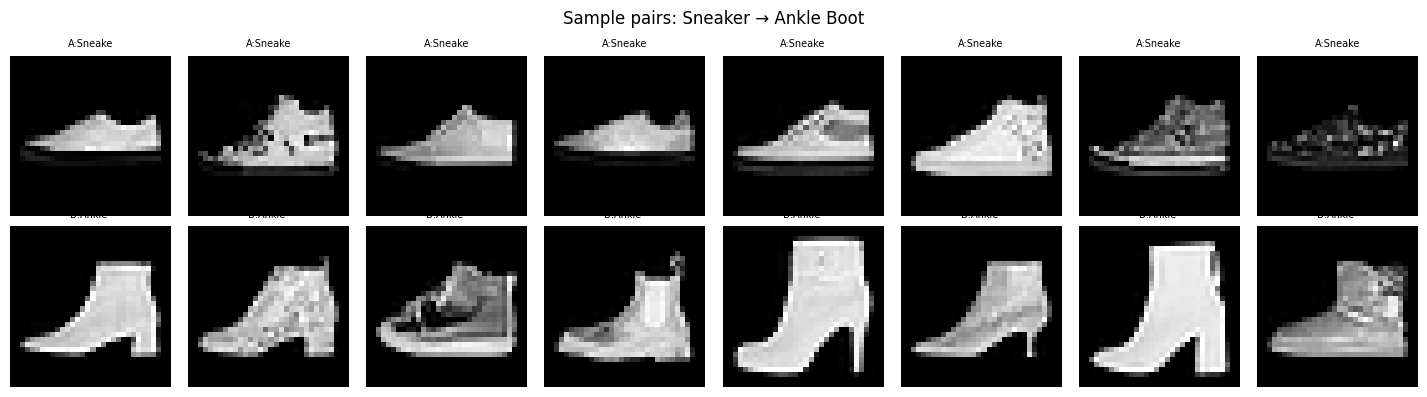

In [8]:
def denorm(x):
    """Convert normalized [-1, 1] tensor to display range [0, 1]."""
    return (x * 0.5 + 0.5).clamp(0, 1)


def show_pair_examples(pair_loader, source_class, target_class, n=8):
    """Display n example source-target pairs from the given DataLoader."""
    x_a, x_b = next(iter(pair_loader))

    fig, axes = plt.subplots(2, n, figsize=(1.8 * n, 4))
    for i in range(n):
        axes[0, i].imshow(denorm(x_a[i]).squeeze(), cmap="gray")
        axes[0, i].set_title(f"A:{FMNIST_CLASS_NAMES[source_class][:6]}", fontsize=7)
        axes[0, i].axis("off")

        axes[1, i].imshow(denorm(x_b[i]).squeeze(), cmap="gray")
        axes[1, i].set_title(f"B:{FMNIST_CLASS_NAMES[target_class][:6]}", fontsize=7)
        axes[1, i].axis("off")

    axes[0, 0].set_ylabel("Source", fontsize=11)
    axes[1, 0].set_ylabel("Target", fontsize=11)
    plt.suptitle(
        f"Sample pairs: {FMNIST_CLASS_NAMES[source_class]} → {FMNIST_CLASS_NAMES[target_class]}"
    )
    plt.tight_layout()
    plt.show()


show_pair_examples(train_loader, SOURCE_CLASS, TARGET_CLASS, n=8)

## 2. Data-to-Data Rectified Flow - Unconditional

Flow Matching logic from Notebook 04 stays identical:

- Sample source/target pair $(x_A, x_B)$
- Sample time $t \in [0,1]$
- Construct point on path: $z_t = (1-t)x_A + t\,x_B$
- Target velocity: $u_t = x_B - x_A$

Only difference: model receives **no semantic conditioning signal**. It is instantiated with `num_classes=1` & always receives the constant dummy condition index `0`. Label embedding is therefore identical for all samples and carries no information -> model is functionally unconditional.

In [9]:
class DataToDataRF:
    """Unconditional Data-to-Data Rectified Flow wrapper.

    Wraps a DiT model and provides:
    - forward(): computes the flow-matching MSE loss for a (x_A, x_B) pair.
    - sample(): integrates the learned vector field from t=0 to t=1.

    The model always receives the constant dummy condition index 0,
    making it functionally unconditional (num_classes=1 in the DiT).
    """

    def __init__(self, model, pairing_mode="random"):
        self.model = model
        if pairing_mode not in {"random", "nn_batch"}:
            raise ValueError("pairing_mode must be 'random' or 'nn_batch'.")
        self.pairing_mode = pairing_mode

    def _dummy_cond(self, batch_size, device):
        """Return a batch of constant zeros as a dummy conditioning index.

        With num_classes=1 the label embedding is always the same vector.
        so the model effectively ignores the conditioning input
        """
        return torch.zeros(batch_size, dtype=torch.long, device=device)

    @torch.no_grad()
    def _match_targets_by_nn(self, x_a, x_b):
        """Optional heuristic pairing inside a batch.

        Keep disabled for strict unpaired experiments. It can be useful as an
        ablation baseline to test whether stronger pairing bias improves metrics
        """
        a_flat = x_a.flatten(start_dim=1)
        b_flat = x_b.flatten(start_dim=1)
        dist = torch.cdist(a_flat, b_flat, p=2)
        nn_idx = dist.argmin(dim=1)
        return x_b[nn_idx]

    def forward(self, x_a, x_b):
        """Compute the flow-matching loss for a batch of source-target pairs.

        Randomly samples t in [0,1], constructs z_t = (1-t)*x_A + t*x_B,
        and minimizes MSE between the predicted and target velocity
        """
        if self.pairing_mode == "nn_batch":
            x_b = self._match_targets_by_nn(x_a, x_b)

        b = x_a.size(0)
        cond = self._dummy_cond(b, x_a.device)

        # Sample a random timestep per sample in the batch
        t = torch.rand((b,), device=x_a.device)
        # Expand t to match the spatial dimensions of the images
        texp = t.view([b, *([1] * len(x_a.shape[1:]))])

        # Interpolated point on the straight-line path between x_A and x_B
        z_t = (1 - texp) * x_a + texp * x_b
        # Ground-truth velocity pointing from source to target
        target_velocity = x_b - x_a

        pred_velocity = self.model(z_t, t, cond)
        loss = F.mse_loss(pred_velocity, target_velocity)

        return loss

    @torch.no_grad()
    def sample(self, x_start, steps=50):
        """Integrate learned vector field from t=0 to t=1.

        Uses a simple Euler scheme with uniform step size dt = 1/steps.
        Returns full trajectory as a list of tensors (length steps+1),
        where index 0 is x_start and index -1 is the generated endpoint
        """
        b = x_start.size(0)
        cond = self._dummy_cond(b, x_start.device)

        dt = 1.0 / steps
        # Broadcast dt to match image shape for element-wise update
        dt_tensor = torch.tensor([dt] * b, device=x_start.device).view(
            [b, *([1] * len(x_start.shape[1:]))]
        )

        z = x_start.clone()
        trajectory = [z.clone()]  # Store all intermediate states

        # Euler integration: z_{t+dt} = z_t + dt * v_theta(z_t, t)
        for i in range(steps):
            t = torch.tensor([(i / steps)] * b, device=x_start.device)
            velocity = self.model(z, t, cond)
            z = z + dt_tensor * velocity
            trajectory.append(z.clone())

        return trajectory

In [10]:
channels = 1  # Grayscale images

# Model-size ablation presets for the main training run
# Important: dim must satisfy GroupNorm constraints in dit.py
# With GroupNorm(32, dim//2), we need (dim//2) % 32 == 0 -> dim must be a multiple of 64
MODEL_PROFILE = "medium"  # Options: small, medium, large
MODEL_CONFIGS = {
    "small": {"dim": 64, "n_layers": 4, "n_heads": 4},
    "medium": {"dim": 128, "n_layers": 6, "n_heads": 8},
    "large": {"dim": 192, "n_layers": 8, "n_heads": 12},
}
if MODEL_PROFILE not in MODEL_CONFIGS:
    raise ValueError("MODEL_PROFILE must be one of: small, medium, large")

cfg = MODEL_CONFIGS[MODEL_PROFILE]

# Instantiate DiT-Llama model
# num_classes=1 ensures the label embedding is always identical -> no conditioning
# class_dropout_prob=0.0 disables classifier-free guidance dropout
model = DiT_Llama(
    channels,
    32,          # Input image size (32x32 after padding)
    dim=cfg["dim"],
    n_layers=cfg["n_layers"],
    n_heads=cfg["n_heads"],
    num_classes=1,
    class_dropout_prob=0.0,
).to(device)

# Strict unpaired baseline uses random pairing (no matching bias)
rf_d2d = DataToDataRF(model, pairing_mode="random")
optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)

model_size = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {model_size:,}")
print("Model profile:", MODEL_PROFILE, cfg)
print("Pairing mode:", rf_d2d.pairing_mode)

# Set FORCE_RETRAIN=True to skip checkpoint loading and train from scratch
# Keep this True after objective/config changes
FORCE_RETRAIN = True

# Training profile: "full" runs 100 epochs with the complete dataset;
# "quick" runs 8 epochs with batched limits for fast iteration
TRAINING_PROFILE = "full"  # "full" (100 epochs) or "quick" (8 epochs)

if TRAINING_PROFILE == "full":
    EPOCHS = 100
    MAX_BATCHES_PER_EPOCH = None   # None = use the full dataloader each epoch
    EVAL_BATCHES_PER_EPOCH = None  # None = evaluate on the full test loader
elif TRAINING_PROFILE == "quick":
    EPOCHS = 8
    MAX_BATCHES_PER_EPOCH = 250
    EVAL_BATCHES_PER_EPOCH = 20
else:
    raise ValueError("TRAINING_PROFILE must be 'full' or 'quick'.")

# Early stopping halts training if validation loss does not improve
USE_EARLY_STOPPING = True
EARLY_STOPPING_PATIENCE = 10     # Number of epochs without improvement before stopping
EARLY_STOPPING_MIN_DELTA = 1e-4  # Minimum improvement to count as progress

# Checkpoint paths -> include profile and pairing for clean experiment separation
run_dir = repo_path / "assets" / "fmnist_d2d_runs"
run_dir.mkdir(parents=True, exist_ok=True)
run_tag = f"{MODEL_PROFILE}_{rf_d2d.pairing_mode}"
latest_ckpt_path = run_dir / f"fmnist_d2d_checkpoint_latest_{run_tag}.pt"
best_ckpt_path = run_dir / f"fmnist_d2d_checkpoint_best_{run_tag}.pt"
LOAD_BEST_IF_AVAILABLE = True  # Prefer the best checkpoint over the latest


def eval_epoch_loss(model_rf, loader, device, max_batches=None):
    """Compute mean MSE loss over the loader in eval mode (no gradients)"""
    model_rf.model.eval()
    total = 0.0
    count = 0

    with torch.no_grad():
        for i, (x_a, x_b) in enumerate(loader):
            if max_batches is not None and i >= max_batches:
                break

            x_a = x_a.to(device)
            x_b = x_b.to(device)

            # Reuse forward() so evaluation matches the active pairing policy
            loss = model_rf.forward(x_a, x_b)

            total += loss.item()
            count += 1

    return total / max(1, count)


# Initialize history lists (will be populated during training or loaded from checkpoint)
loss_history = []
train_loss_history = []
val_loss_history = []
trained_this_session = False

# Determine which checkpoint to load, if any
load_path = None
if LOAD_BEST_IF_AVAILABLE and best_ckpt_path.exists():
    load_path = best_ckpt_path
elif latest_ckpt_path.exists():
    load_path = latest_ckpt_path

if load_path is not None and not FORCE_RETRAIN:
    # --- Load existing checkpoint ---
    payload = torch.load(load_path, map_location=device)

    if isinstance(payload, dict) and "model_state_dict" in payload:
        # Modern checkpoint format: includes model, optimizer, and history
        rf_d2d.model.load_state_dict(payload["model_state_dict"])
        if "optimizer_state_dict" in payload:
            optimizer.load_state_dict(payload["optimizer_state_dict"])
        loss_history = payload.get("loss_history", [])
        train_loss_history = payload.get("train_loss_history", loss_history)
        val_loss_history = payload.get("val_loss_history", [])
        print("Loaded checkpoint from:", load_path)
    else:
        # Legacy format: plain state dict without metadata
        rf_d2d.model.load_state_dict(payload)
        print("Loaded legacy state_dict checkpoint from:", load_path)

else:
    # --- Train from scratch ---
    trained_this_session = True

    best_val_loss = float("inf")
    best_epoch = -1
    epochs_no_improve = 0

    for epoch in range(EPOCHS):
        rf_d2d.model.train()
        running = 0.0

        # Optionally limit steps per epoch for the "quick" profile
        steps_limit = (
            len(train_loader)
            if MAX_BATCHES_PER_EPOCH is None
            else min(MAX_BATCHES_PER_EPOCH, len(train_loader))
        )

        for step, (x_a, x_b) in enumerate(train_loader):
            if step >= steps_limit:
                break

            x_a = x_a.to(device)
            x_b = x_b.to(device)

            optimizer.zero_grad()
            loss = rf_d2d.forward(x_a, x_b)
            loss.backward()
            optimizer.step()

            running += loss.item()

        # Record per-epoch losses.
        train_epoch_loss = running / max(1, steps_limit)
        val_epoch_loss = eval_epoch_loss(
            rf_d2d, test_loader, device, max_batches=EVAL_BATCHES_PER_EPOCH
        )

        train_loss_history.append(train_epoch_loss)
        val_loss_history.append(val_epoch_loss)
        loss_history.append(train_epoch_loss)

        print(
            f"Epoch {epoch + 1:03d}/{EPOCHS} "
            f"| train: {train_epoch_loss:.5f} "
            f"| val: {val_epoch_loss:.5f}"
        )

        # Build checkpoint payload with model state, optimizer state, and metadata
        latest_payload = {
            "model_state_dict": rf_d2d.model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "loss_history": loss_history,
            "train_loss_history": train_loss_history,
            "val_loss_history": val_loss_history,
            "best_val_loss": best_val_loss,
            "best_epoch": best_epoch,
            "config": {
                "dataset": "FashionMNIST",
                "source_class": SOURCE_CLASS,
                "target_class": TARGET_CLASS,
                "channels": channels,
                "img_size": 32,
                "dim": cfg["dim"],
                "n_layers": cfg["n_layers"],
                "n_heads": cfg["n_heads"],
                "num_classes": 1,
                "conditioning": "none",
                "pairing_mode": rf_d2d.pairing_mode,
                "model_profile": MODEL_PROFILE,
                "training_profile": TRAINING_PROFILE,
                "epochs": EPOCHS,
            },
        }
        # Save latest checkpoint every epoch so interrupted runs can be resumed
        torch.save(latest_payload, latest_ckpt_path)

        # Update best checkpoint if validation loss improved sufficiently
        improvement = best_val_loss - val_epoch_loss
        if improvement > EARLY_STOPPING_MIN_DELTA:
            best_val_loss = val_epoch_loss
            best_epoch = epoch + 1
            epochs_no_improve = 0
            torch.save(latest_payload, best_ckpt_path)
            print(f"  New best checkpoint (epoch {best_epoch}, val {best_val_loss:.5f})")
        else:
            epochs_no_improve += 1

        # Stop early if no improvement for EARLY_STOPPING_PATIENCE consecutive epochs
        if USE_EARLY_STOPPING and epochs_no_improve >= EARLY_STOPPING_PATIENCE:
            print(
                "Early stopping triggered "
                f"after {epoch + 1} epochs (best epoch: {best_epoch}, best val: {best_val_loss:.5f})."
            )
            break

print("trained_this_session:", trained_this_session)
print("Checkpoint (latest):", latest_ckpt_path)
print("Checkpoint (best):", best_ckpt_path)

Trainable parameters: 2,393,796
Model profile: medium {'dim': 128, 'n_layers': 6, 'n_heads': 8}
Pairing mode: random
Epoch 001/100 | train: 0.12201 | val: 0.06433
  New best checkpoint (epoch 1, val 0.06433)
Epoch 002/100 | train: 0.06165 | val: 0.05652
  New best checkpoint (epoch 2, val 0.05652)
Epoch 003/100 | train: 0.05437 | val: 0.05299
  New best checkpoint (epoch 3, val 0.05299)
Epoch 004/100 | train: 0.04934 | val: 0.04578
  New best checkpoint (epoch 4, val 0.04578)
Epoch 005/100 | train: 0.04662 | val: 0.04427
  New best checkpoint (epoch 5, val 0.04427)
Epoch 006/100 | train: 0.04410 | val: 0.04304
  New best checkpoint (epoch 6, val 0.04304)
Epoch 007/100 | train: 0.04356 | val: 0.04137
  New best checkpoint (epoch 7, val 0.04137)
Epoch 008/100 | train: 0.04148 | val: 0.04240
Epoch 009/100 | train: 0.04019 | val: 0.03928
  New best checkpoint (epoch 9, val 0.03928)
Epoch 010/100 | train: 0.03919 | val: 0.03804
  New best checkpoint (epoch 10, val 0.03804)
Epoch 011/100 | t

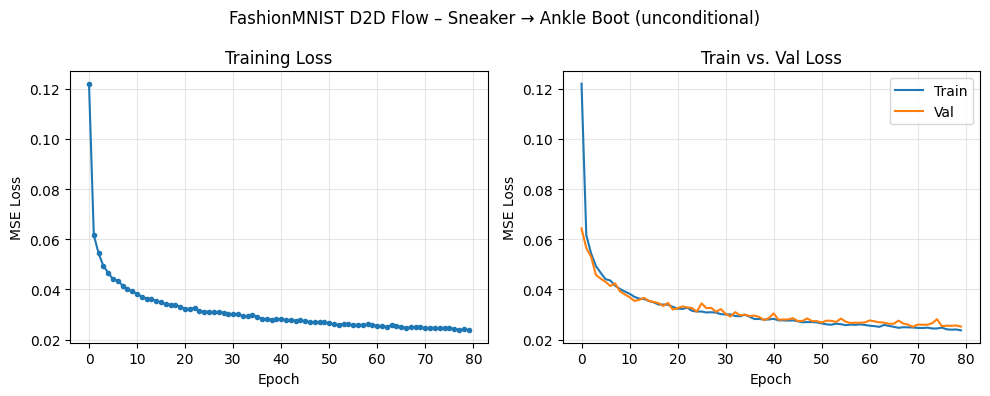

In [11]:
# Plot training and validation loss curves side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

if len(train_loss_history) > 0:
    axes[0].plot(train_loss_history, marker="o", markersize=3, label="Train")
    axes[0].set_title("Training Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("MSE Loss")
    axes[0].grid(alpha=0.3)

if len(val_loss_history) > 0:
    # Overlay train + val on right panel to assess overfitting
    axes[1].plot(train_loss_history, label="Train")
    axes[1].plot(val_loss_history, label="Val")
    axes[1].set_title("Train vs. Val Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("MSE Loss")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

plt.suptitle(
    f"FashionMNIST D2D Flow – {FMNIST_CLASS_NAMES[SOURCE_CLASS]} → "
    f"{FMNIST_CLASS_NAMES[TARGET_CLASS]} (unconditional)"
)
plt.tight_layout()
plt.show()

### 2.1 Evaluation on Held-Out Test Pairs

Evaluate model on the test loader in `eval` mode for a clean generalization estimate.

In [12]:
@torch.no_grad()
def evaluate_on_test_loader(model_rf, loader, device, max_batches=None):
    """Evaluate flow-matching MSE loss on the test loader in eval mode.

    Returns (mean_loss, number_of_batches_evaluated)
    """
    model_rf.model.eval()

    total_loss = 0.0
    total_batches = 0

    for i, (x_a, x_b) in enumerate(loader):
        if max_batches is not None and i >= max_batches:
            break

        x_a = x_a.to(device)
        x_b = x_b.to(device)

        # Reuse forward() so test loss is consistent with the active pairing policy
        loss = model_rf.forward(x_a, x_b)

        total_loss += loss.item()
        total_batches += 1

    return total_loss / max(1, total_batches), total_batches


# Set to None for the full test set, or a small number for a quick sanity check
EVAL_MAX_BATCHES = None

test_loss, n_eval_batches = evaluate_on_test_loader(
    rf_d2d, test_loader, device, max_batches=EVAL_MAX_BATCHES
)

print(f"Eval mode active: {not rf_d2d.model.training}")
print(f"Evaluated batches: {n_eval_batches}")
print(f"Mean test MSE loss: {test_loss:.6f}")

# Show last recorded train/val entries as a quick generalization check
if "train_loss_history" in globals() and len(train_loss_history) > 0:
    print(f"Last train loss: {train_loss_history[-1]:.6f}")
if "val_loss_history" in globals() and len(val_loss_history) > 0:
    print(f"Last val loss (during training): {val_loss_history[-1]:.6f}")
if (
    "train_loss_history" in globals()
    and "val_loss_history" in globals()
    and len(train_loss_history) > 0
    and len(val_loss_history) > 0
):
    gap = val_loss_history[-1] - train_loss_history[-1]
    print(f"Generalization gap (val-train): {gap:+.6f}")

Eval mode active: True
Evaluated batches: 40
Mean test MSE loss: 0.024544
Last train loss: 0.023685
Last val loss (during training): 0.025205
Generalization gap (val-train): +0.001520


## 3. Experiments (analogous to Notebook 04)

Comparison of two interpolation strategies for a concrete source-target pair:

1. **Linear interpolation** as baseline
2. **Learned flow** from the unconditional model

In [13]:
@torch.no_grad()
def linear_interpolation(x_a, x_b, steps=9):
    """Produce a list of linearly interpolated images between x_A and x_B.

    Returns 'steps' evenly spaced frames from t=0 (x_A) to t=1 (x_B)
    """
    ts = torch.linspace(0, 1, steps, device=x_a.device)
    return [(1 - t) * x_a + t * x_b for t in ts]


@torch.no_grad()
def run_flow_trajectory(model_rf, x_a, steps=50, n_vis=9):
    """Run flow model from x_A and return a visual subset and full trajectory

    Returns:
        vis_frames: n_vis evenly spaced frames from the full trajectory
        full_traj:  complete list of steps+1 tensors (for downstream analysis)
    """
    traj = model_rf.sample(x_a, steps=steps)
    # Select n_vis evenly spaced indices for visualization
    idxs = torch.linspace(0, len(traj) - 1, n_vis).long().tolist()
    return [traj[i] for i in idxs], traj


def plot_two_rows(images_top, images_bottom, title_top, title_bottom, main_title):
    """Display two rows of images with row labels and a shared title"""
    n = len(images_top)
    fig, axes = plt.subplots(2, n, figsize=(1.8 * n, 4.2))

    for i in range(n):
        axes[0, i].imshow(denorm(images_top[i]).squeeze(), cmap="gray")
        axes[0, i].axis("off")

        axes[1, i].imshow(denorm(images_bottom[i]).squeeze(), cmap="gray")
        axes[1, i].axis("off")

    axes[0, 0].set_ylabel(title_top, fontsize=10)
    axes[1, 0].set_ylabel(title_bottom, fontsize=10)
    plt.suptitle(main_title)
    plt.tight_layout()
    plt.show()

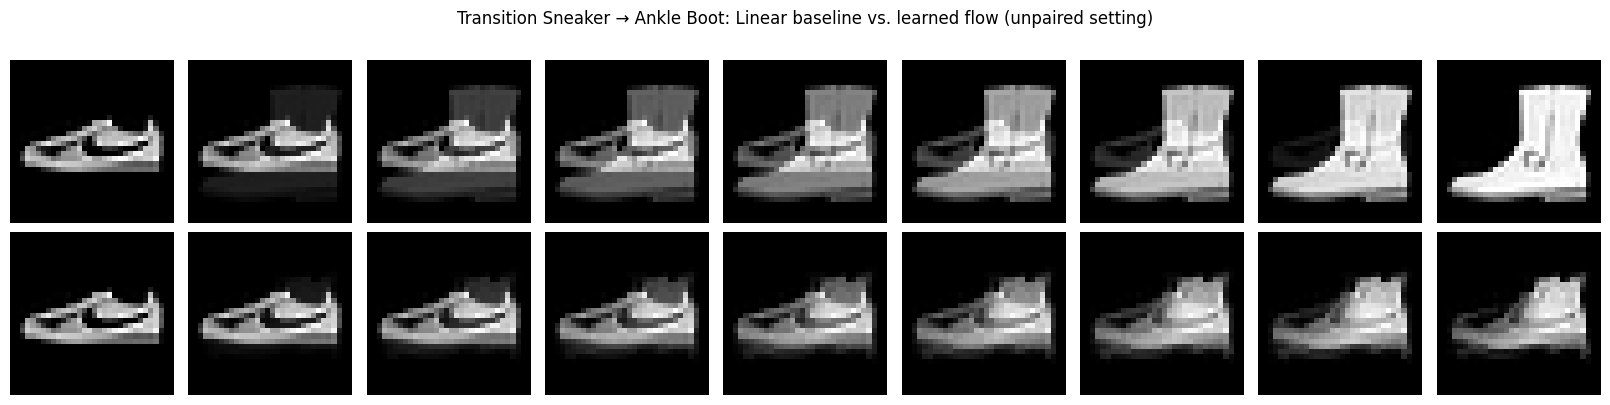

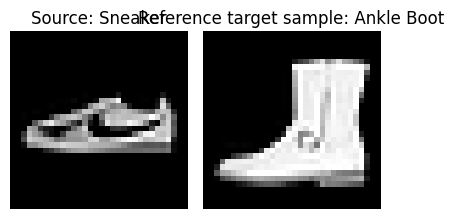

Saved latest trajectory to: /content/minRF_interpolation/assets/fmnist_d2d_runs/fmnist_d2d_trajectory_latest.pt


In [14]:
# Sample one source image and one random target-class reference image
# In unpaired setting, x_b is *not* a ground-truth paired endpoint for x_a
idx_a = random.choice(test_label_index[SOURCE_CLASS])
idx_b = random.choice(test_label_index[TARGET_CLASS])

x_a, _ = test_dataset[idx_a]
x_b, _ = test_dataset[idx_b]

# Add batch dimension & move to device
x_a = x_a.unsqueeze(0).to(device)
x_b = x_b.unsqueeze(0).to(device)

# Compute linear & flow trajectories for this pair
lin_steps = linear_interpolation(x_a, x_b, steps=9)
flow_vis, flow_full = run_flow_trajectory(rf_d2d, x_a, steps=50, n_vis=9)

# Side-by-side comparison of both interpolation strategies
plot_two_rows(
    images_top=[img[0].detach().cpu() for img in lin_steps],
    images_bottom=[img[0].detach().cpu() for img in flow_vis],
    title_top="Linear",
    title_bottom="Flow",
    main_title=(
        f"Transition {FMNIST_CLASS_NAMES[SOURCE_CLASS]} → {FMNIST_CLASS_NAMES[TARGET_CLASS]}: "
        "Linear baseline vs. learned flow (unpaired setting)"
    ),
)

# Show source and one random target-class reference sample
fig, ax = plt.subplots(1, 2, figsize=(4, 2.2))
ax[0].imshow(denorm(x_a[0].detach().cpu()).squeeze(), cmap="gray")
ax[0].set_title(f"Source: {FMNIST_CLASS_NAMES[SOURCE_CLASS]}")
ax[0].axis("off")
ax[1].imshow(denorm(x_b[0].detach().cpu()).squeeze(), cmap="gray")
ax[1].set_title(f"Reference target sample: {FMNIST_CLASS_NAMES[TARGET_CLASS]}")
ax[1].axis("off")
plt.tight_layout()
plt.show()

# Persist the latest trajectory for later analysis without re-running everything
traj_path = run_dir / "fmnist_d2d_trajectory_latest.pt"
traj_payload = {
    "trajectory": torch.stack([t.detach().cpu() for t in flow_full], dim=0),
    "source": x_a.detach().cpu(),
    "target": x_b.detach().cpu(),
    "source_class": SOURCE_CLASS,
    "target_class": TARGET_CLASS,
}
torch.save(traj_payload, traj_path)
print("Saved latest trajectory to:", traj_path)

In [15]:
@torch.no_grad()
def build_class_reference_bank(dataset, label_index, label, max_items=1000, seed=42):
    """Create a tensor bank of random samples from one class for unpaired diagnostics"""
    ids = label_index[label]
    if len(ids) == 0:
        raise ValueError(f"No samples found for label {label}.")

    rng = random.Random(seed)
    pick = min(max_items, len(ids))
    chosen = rng.sample(ids, pick)

    xs = []
    for i in chosen:
        x_i, _ = dataset[i]
        xs.append(x_i)

    return torch.stack(xs, dim=0)


@torch.no_grad()
def min_l1_to_bank(x, bank):
    """Return the minimum per-pixel L1 distance from x to any sample in bank"""
    x_cpu = x.detach().cpu()
    d = (bank - x_cpu).abs().flatten(start_dim=1).mean(dim=1)
    return float(d.min().item())


@torch.no_grad()
def endpoint_metrics_unpaired(x_a, x_b_ref, flow_full, target_bank):
    """Compute endpoint diagnostics suitable for the unpaired setup.

    Important: x_b_ref is only one random reference sample from the target class,
    not a paired supervision target for x_a
    """
    flow_end = flow_full[-1]

    return {
        "flow_l1_to_reference_target": (flow_end - x_b_ref).abs().mean().item(),
        "flow_l1_to_target_bank_nn": min_l1_to_bank(flow_end, target_bank),
        "source_l1_to_target_bank_nn": min_l1_to_bank(x_a, target_bank),
        "reference_target_l1_to_target_bank_nn": min_l1_to_bank(x_b_ref, target_bank),
        "flow_l1_to_source": (flow_end - x_a).abs().mean().item(),
    }


target_bank = build_class_reference_bank(
    dataset=test_dataset,
    label_index=test_label_index,
    label=TARGET_CLASS,
    max_items=1000,
    seed=SEED,
)

m = endpoint_metrics_unpaired(x_a, x_b, flow_full, target_bank)
print("Unpaired endpoint diagnostics for selected example")
print("  Flow   L1(end, reference target):", f"{m['flow_l1_to_reference_target']:.4f}")
print("  Flow   L1(end, nearest target-bank sample):", f"{m['flow_l1_to_target_bank_nn']:.4f}")
print("  Source L1(source, nearest target-bank sample):", f"{m['source_l1_to_target_bank_nn']:.4f}")
print("  RefTar L1(reference target, nearest target-bank sample):", f"{m['reference_target_l1_to_target_bank_nn']:.4f}")
print("  Flow   L1(end, source):", f"{m['flow_l1_to_source']:.4f}")

Unpaired endpoint diagnostics for selected example
  Flow   L1(end, reference target): 0.4356
  Flow   L1(end, nearest target-bank sample): 0.0765
  Source L1(source, nearest target-bank sample): 0.1423
  RefTar L1(reference target, nearest target-bank sample): 0.0000
  Flow   L1(end, source): 0.1706


## 3.1 Semantic Transition – FashionMNIST Classifier

To evaluate beyond pixel loss, a small CNN classifier is trained on FashionMNIST. It measures along the trajectory:

- Confidence for the target class (Ankle Boot)
- Predicted class at each step
- How smooth is the semantic transition?

In [16]:
class FashionMNISTEvalClassifier(nn.Module):
    """Small CNN classifier for semantic trajectory evaluation on FashionMNIST.

    Trained on all 10 classes to serve as a proxy for semantic class identity.
    Used only for evaluation -> not involved in flow model training
    """

    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),                           # 32x32 → 16x16
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),                           # 16x16 → 8x8
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, 10),                        # 10 FashionMNIST classes
        )

    def forward(self, x):
        return self.net(x)


@torch.no_grad()
def classifier_probs(model, x_batch):
    """Return softmax class probabilities for a batch of images."""
    model.eval()
    logits = model(x_batch)
    return torch.softmax(logits, dim=1)


# Load classifier from checkpoint if available; otherwise train it once
clf_path = run_dir / "fmnist_eval_classifier.pt"
eval_clf = FashionMNISTEvalClassifier().to(device)

if clf_path.exists():
    eval_clf.load_state_dict(torch.load(clf_path, map_location=device))
    print("Loaded classifier checkpoint:", clf_path)
else:
    print("Training evaluation classifier...")
    clf_epochs = 5
    clf_max_batches = 400  # Cap to speed up training; still gives good accuracy

    # Train on the full FashionMNIST training set (all 10 classes)
    clf_train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, drop_last=True)
    clf_opt = torch.optim.Adam(eval_clf.parameters(), lr=1e-3)
    clf_loss_fn = nn.CrossEntropyLoss()

    for ep in range(clf_epochs):
        eval_clf.train()
        running = 0.0
        steps = 0

        for i, (x, y) in enumerate(clf_train_loader):
            if i >= clf_max_batches:
                break

            x = x.to(device)
            y = y.to(device)

            clf_opt.zero_grad()
            logits = eval_clf(x)
            loss = clf_loss_fn(logits, y)
            loss.backward()
            clf_opt.step()

            running += loss.item()
            steps += 1

        print(f"Classifier epoch {ep + 1}/{clf_epochs} | loss: {running / max(1, steps):.4f}")

    torch.save(eval_clf.state_dict(), clf_path)
    print("Saved classifier checkpoint:", clf_path)


@torch.no_grad()
def trajectory_semantic_curve(eval_model, trajectory_list, target_label):
    """Compute per-step target-class confidence and predicted class along a trajectory.

    Returns:
        probs_list: list of floats -> p(target_label) at each trajectory step
        pred_list:  list of ints   -> argmax predicted class at each step
    """
    probs_list = []
    pred_list = []

    for z in trajectory_list:
        p = classifier_probs(eval_model, z.to(device))[0].detach().cpu()
        probs_list.append(float(p[target_label]))
        pred_list.append(int(torch.argmax(p).item()))

    return probs_list, pred_list

Training evaluation classifier...
Classifier epoch 1/5 | loss: 0.5589
Classifier epoch 2/5 | loss: 0.3445
Classifier epoch 3/5 | loss: 0.2933
Classifier epoch 4/5 | loss: 0.2620
Classifier epoch 5/5 | loss: 0.2376
Saved classifier checkpoint: /content/minRF_interpolation/assets/fmnist_d2d_runs/fmnist_eval_classifier.pt


Step | Flow pred | Flow p(target) | Linear pred | Linear p(target)
   0 |         7 |         0.0001 |           7 |           0.0001
   5 |         7 |         0.0004 |           7 |           0.0008
  10 |         7 |         0.0026 |           7 |           0.0122
  15 |         7 |         0.0119 |           7 |           0.1594
  20 |         7 |         0.0483 |           9 |           0.7241
  25 |         7 |         0.1450 |           9 |           0.9437
  30 |         7 |         0.3024 |           9 |           0.9844
  35 |         7 |         0.4782 |           9 |           0.9948
  40 |         9 |         0.6305 |           9 |           0.9975
  45 |         9 |         0.7037 |           9 |           0.9987
  50 |         9 |         0.7258 |           9 |           0.9993


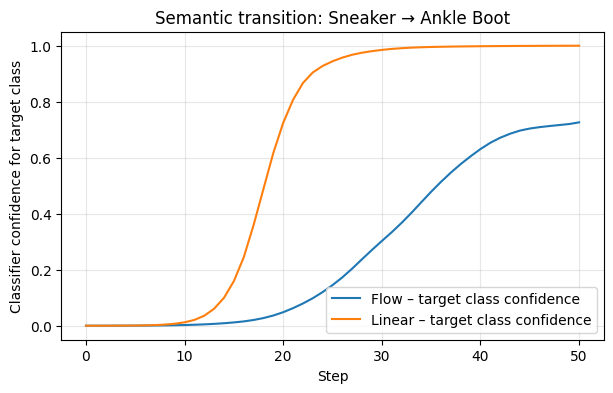

In [17]:
# Compute semantic confidence curves for the current example
steps_for_eval = 51
linear_full = linear_interpolation(x_a, x_b, steps=steps_for_eval)
_, flow_full_eval = run_flow_trajectory(rf_d2d, x_a, steps=50, n_vis=9)

flow_target_conf, flow_pred = trajectory_semantic_curve(eval_clf, flow_full_eval, TARGET_CLASS)
lin_target_conf, lin_pred = trajectory_semantic_curve(eval_clf, linear_full, TARGET_CLASS)

# Print a step-by-step comparison table (every 5th step for readability)
print("Step | Flow pred | Flow p(target) | Linear pred | Linear p(target)")
for s in range(0, min(len(flow_target_conf), len(lin_target_conf)), 5):
    print(
        f"{s:>4} |"
        f" {flow_pred[s]:>9} | {flow_target_conf[s]:>14.4f} |"
        f" {lin_pred[s]:>11} | {lin_target_conf[s]:>16.4f}"
    )

# Plot target-class confidence along both trajectories
plt.figure(figsize=(7, 4))
plt.plot(flow_target_conf, label="Flow – target class confidence")
plt.plot(lin_target_conf, label="Linear – target class confidence")
plt.xlabel("Step")
plt.ylabel("Classifier confidence for target class")
plt.title(
    f"Semantic transition: {FMNIST_CLASS_NAMES[SOURCE_CLASS]} → {FMNIST_CLASS_NAMES[TARGET_CLASS]}"
)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### Interpretation of the Classifier Curve

- **Step:** Position along the generated trajectory (0 = source, final step = generated endpoint)
- **Flow pred:** Predicted class label of the Flow-generated intermediate state
- **Flow p(target):** Classifier confidence for the target class (Ankle Boot) along the flow
- **Linear pred:** Predicted class label of the linearly interpolated sample
- **Linear p(target):** Classifier confidence for the target class under linear interpolation

### 3.2 Random-Pair Distribution Evaluation

Aggregated evaluation over many random source-target pairs:

- Endpoint accuracy for the target class
- Final target-class confidence
- Monotonicity (how consistently does confidence increase?)
- Manifold confidence (mean classifier certainty along the path)

In [18]:
@torch.no_grad()
def evaluate_mapping_distribution(
    eval_model,
    flow_model,
    source_label,
    target_label,
    n_pairs=100,
    steps=50,
):
    """Aggregate semantic evaluation metrics over n_pairs random unpaired samples.

    For each pair, both a linear & a flow trajectory are generated and evaluated
    by the classifier. Returns a dict with:
    - endpoint accuracy (fraction of final states classified as target_label)
    - mean final target-class confidence
    - monotonicity (fraction of steps where target confidence increases)
    - manifold confidence (mean max-softmax along the trajectory)
    """
    flow_endpoint_correct = 0
    linear_endpoint_correct = 0

    flow_target_conf_final = []
    linear_target_conf_final = []

    flow_monotonicity = []
    linear_monotonicity = []

    # Average max-softmax as a proxy for staying on the data manifold
    flow_manifold_conf = []
    linear_manifold_conf = []

    for _ in range(n_pairs):
        # Draw an independent random source and target image
        idx_a = random.choice(test_label_index[source_label])
        idx_b = random.choice(test_label_index[target_label])

        x_a_local, _ = test_dataset[idx_a]
        x_b_local, _ = test_dataset[idx_b]

        x_a_local = x_a_local.unsqueeze(0).to(device)
        x_b_local = x_b_local.unsqueeze(0).to(device)

        # Generate linear and flow trajectories for this pair
        linear_traj = linear_interpolation(x_a_local, x_b_local, steps=steps + 1)
        _, flow_traj = run_flow_trajectory(flow_model, x_a_local, steps=steps, n_vis=9)

        # Collect classifier probability distributions at each step
        flow_probs = []
        linear_probs = []

        for zf, zl in zip(flow_traj, linear_traj):
            p_f = classifier_probs(eval_model, zf.to(device))[0].detach().cpu()
            p_l = classifier_probs(eval_model, zl.to(device))[0].detach().cpu()
            flow_probs.append(p_f)
            linear_probs.append(p_l)

        # Stack to [T, 10] for easy per-step indexing
        flow_probs = torch.stack(flow_probs, dim=0)
        linear_probs = torch.stack(linear_probs, dim=0)

        # Check whether the final generated state is classified as the target
        flow_final_pred = int(torch.argmax(flow_probs[-1]).item())
        linear_final_pred = int(torch.argmax(linear_probs[-1]).item())

        flow_endpoint_correct += int(flow_final_pred == target_label)
        linear_endpoint_correct += int(linear_final_pred == target_label)

        # Final target-class confidence
        flow_target_conf_final.append(float(flow_probs[-1, target_label]))
        linear_target_conf_final.append(float(linear_probs[-1, target_label]))

        # Monotonicity: fraction of consecutive steps where target confidence increases
        flow_diff = flow_probs[1:, target_label] - flow_probs[:-1, target_label]
        linear_diff = linear_probs[1:, target_label] - linear_probs[:-1, target_label]
        flow_monotonicity.append(float((flow_diff > 0).float().mean().item()))
        linear_monotonicity.append(float((linear_diff > 0).float().mean().item()))

        # Manifold confidence: mean of the highest softmax probability at each step
        flow_manifold_conf.append(float(flow_probs.max(dim=1).values.mean().item()))
        linear_manifold_conf.append(float(linear_probs.max(dim=1).values.mean().item()))

    return {
        "source_label": source_label,
        "target_label": target_label,
        "n_pairs": n_pairs,
        "flow_endpoint_acc": flow_endpoint_correct / n_pairs,
        "linear_endpoint_acc": linear_endpoint_correct / n_pairs,
        "flow_final_target_conf": float(torch.tensor(flow_target_conf_final).mean().item()),
        "linear_final_target_conf": float(torch.tensor(linear_target_conf_final).mean().item()),
        "flow_monotonicity": float(torch.tensor(flow_monotonicity).mean().item()),
        "linear_monotonicity": float(torch.tensor(linear_monotonicity).mean().item()),
        "flow_manifold_conf": float(torch.tensor(flow_manifold_conf).mean().item()),
        "linear_manifold_conf": float(torch.tensor(linear_manifold_conf).mean().item()),
    }


mapping_result = evaluate_mapping_distribution(
    eval_model=eval_clf,
    flow_model=rf_d2d,
    source_label=SOURCE_CLASS,
    target_label=TARGET_CLASS,
    n_pairs=100,
    steps=50,
)

print(
    f"Random-pair semantic evaluation "
    f"({FMNIST_CLASS_NAMES[SOURCE_CLASS]} → {FMNIST_CLASS_NAMES[TARGET_CLASS]}, n=100)"
)
for k, v in mapping_result.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")
    else:
        print(f"  {k}: {v}")

Random-pair semantic evaluation (Sneaker → Ankle Boot, n=100)
  source_label: 7
  target_label: 9
  n_pairs: 100
  flow_endpoint_acc: 0.8000
  linear_endpoint_acc: 0.9900
  flow_final_target_conf: 0.7495
  linear_final_target_conf: 0.9682
  flow_monotonicity: 0.9276
  linear_monotonicity: 0.9820
  flow_manifold_conf: 0.8376
  linear_manifold_conf: 0.9103


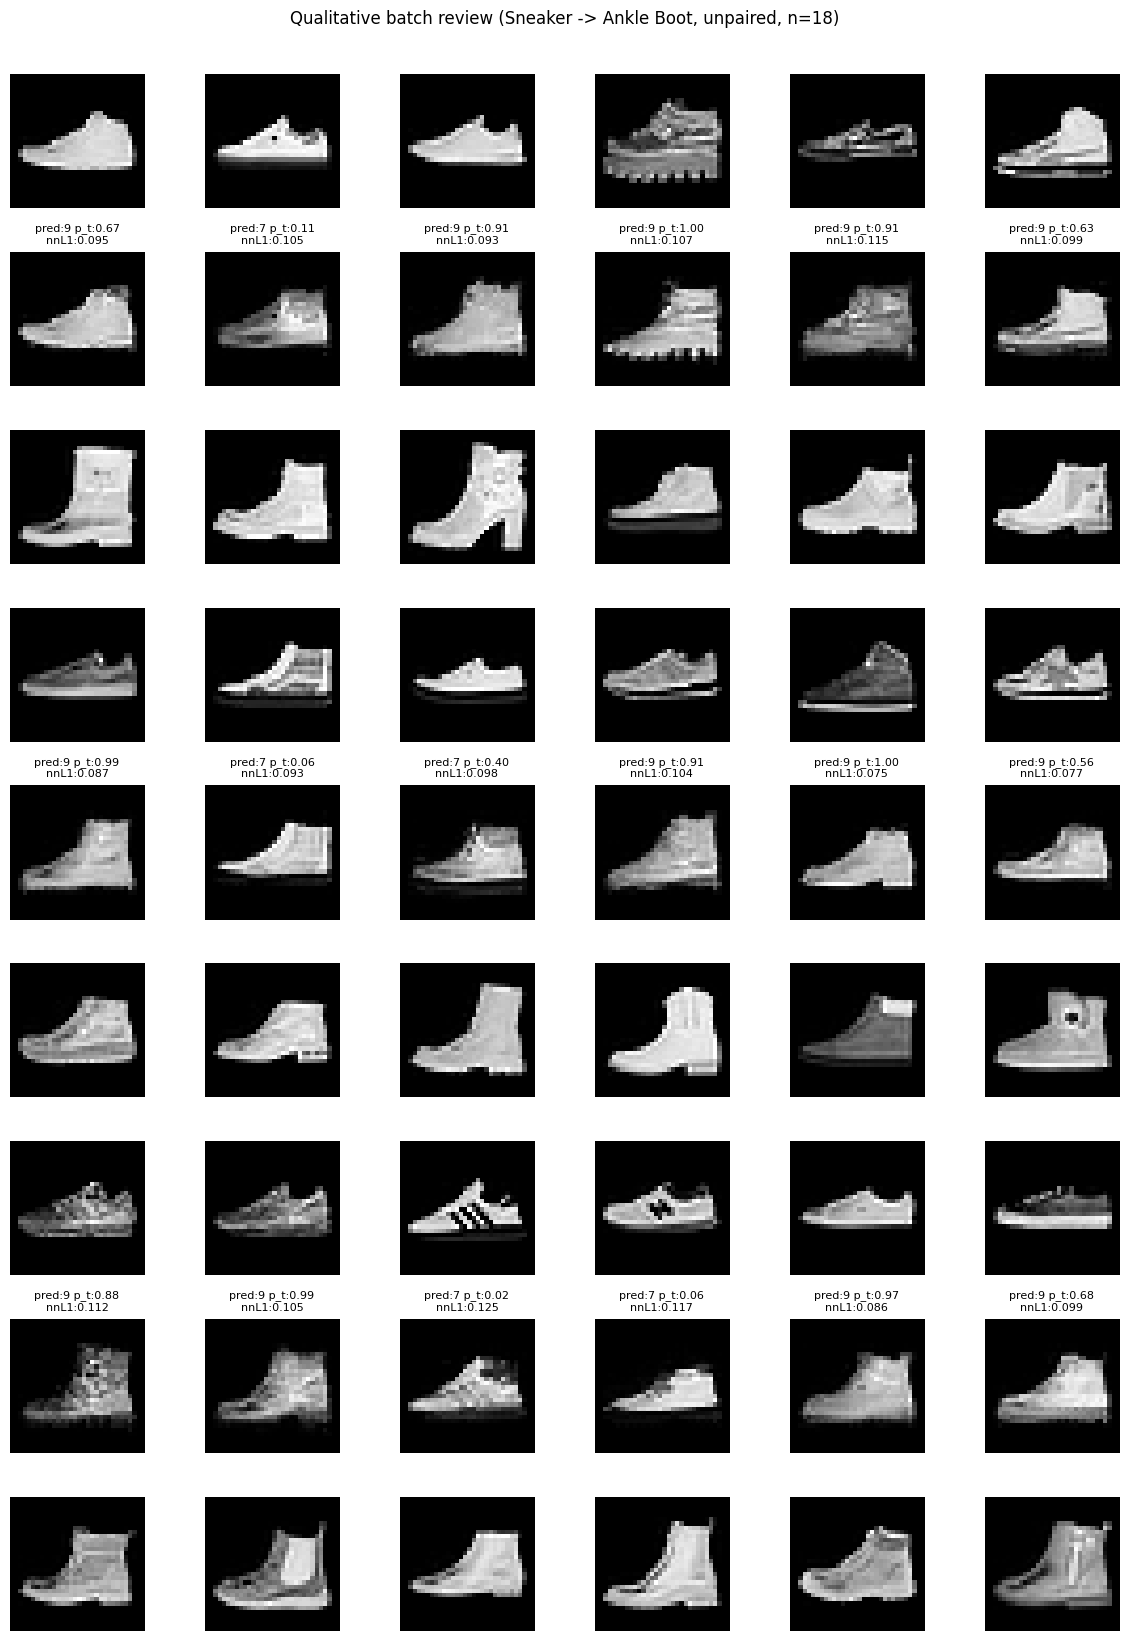

Qualitative batch summary
  endpoint class==target rate: 0.722
  mean endpoint p(target):     0.652
  mean endpoint NN-L1 to target bank: 0.100


In [19]:
import numpy as np

@torch.no_grad()
def qualitative_batch_review(
    flow_model,
    eval_model,
    source_label,
    target_label,
    n_examples=18,
    steps=50,
    max_cols=6,
):
    """Visual review for multiple unpaired trajectories.

    For each example, show source, flow endpoint, and one random target reference.
    Also report endpoint semantic stats over all sampled examples
    """
    if "target_bank" not in globals():
        local_target_bank = build_class_reference_bank(
            dataset=test_dataset,
            label_index=test_label_index,
            label=target_label,
            max_items=1000,
            seed=SEED,
        )
    else:
        local_target_bank = target_bank

    rows = int(np.ceil(n_examples / max_cols))
    fig, axes = plt.subplots(rows * 3, max_cols, figsize=(2.0 * max_cols, 1.8 * rows * 3))

    # Normalize axes shape for n_examples=1 edge case
    if rows * 3 == 1 and max_cols == 1:
        axes = np.array([[axes]])
    elif rows * 3 == 1:
        axes = np.array([axes])
    elif max_cols == 1:
        axes = np.array([[ax] for ax in axes])

    endpoint_is_target = []
    endpoint_target_conf = []
    endpoint_nn_l1 = []

    for k in range(rows * max_cols):
        r_block = (k // max_cols) * 3
        c = k % max_cols

        for rr in range(3):
            axes[r_block + rr, c].axis("off")

        if k >= n_examples:
            continue

        idx_a = random.choice(test_label_index[source_label])
        idx_b = random.choice(test_label_index[target_label])

        x_a_local, _ = test_dataset[idx_a]
        x_b_ref, _ = test_dataset[idx_b]

        x_a_local = x_a_local.unsqueeze(0).to(device)
        x_b_ref = x_b_ref.unsqueeze(0).to(device)

        _, flow_traj = run_flow_trajectory(flow_model, x_a_local, steps=steps, n_vis=9)
        flow_end = flow_traj[-1]

        p_end = classifier_probs(eval_model, flow_end.to(device))[0].detach().cpu()
        pred_end = int(torch.argmax(p_end).item())
        p_target_end = float(p_end[target_label])
        nn_l1 = min_l1_to_bank(flow_end, local_target_bank)

        endpoint_is_target.append(int(pred_end == target_label))
        endpoint_target_conf.append(p_target_end)
        endpoint_nn_l1.append(nn_l1)

        axes[r_block + 0, c].imshow(denorm(x_a_local[0].detach().cpu()).squeeze(), cmap="gray")
        if c == 0:
            axes[r_block + 0, c].set_ylabel("Source", fontsize=9)

        axes[r_block + 1, c].imshow(denorm(flow_end[0].detach().cpu()).squeeze(), cmap="gray")
        if c == 0:
            axes[r_block + 1, c].set_ylabel("Flow end", fontsize=9)
        axes[r_block + 1, c].set_title(
            f"pred:{pred_end} p_t:{p_target_end:.2f}\nnnL1:{nn_l1:.3f}", fontsize=8
        )

        axes[r_block + 2, c].imshow(denorm(x_b_ref[0].detach().cpu()).squeeze(), cmap="gray")
        if c == 0:
            axes[r_block + 2, c].set_ylabel("Target ref", fontsize=9)

    plt.suptitle(
        f"Qualitative batch review ({FMNIST_CLASS_NAMES[source_label]} -> "
        f"{FMNIST_CLASS_NAMES[target_label]}, unpaired, n={n_examples})",
        y=1.01,
    )
    plt.tight_layout()
    plt.show()

    endpoint_acc = float(np.mean(endpoint_is_target)) if endpoint_is_target else float("nan")
    mean_target_conf = float(np.mean(endpoint_target_conf)) if endpoint_target_conf else float("nan")
    mean_nn_l1 = float(np.mean(endpoint_nn_l1)) if endpoint_nn_l1 else float("nan")

    print("Qualitative batch summary")
    print(f"  endpoint class==target rate: {endpoint_acc:.3f}")
    print(f"  mean endpoint p(target):     {mean_target_conf:.3f}")
    print(f"  mean endpoint NN-L1 to target bank: {mean_nn_l1:.3f}")


qualitative_batch_review(
    flow_model=rf_d2d,
    eval_model=eval_clf,
    source_label=SOURCE_CLASS,
    target_label=TARGET_CLASS,
    n_examples=18,
    steps=50,
    max_cols=6,
)

In [20]:
# Capacity-vs-performance ablation under strict unpaired training
# This helps distinguish model-underfitting from method-level limitations

@torch.no_grad()
def _summarize_ablation_rows(rows):
    if len(rows) == 0:
        print("No ablation rows to summarize.")
        return

    print("\nAblation summary (higher is better except train/test loss)")
    print("profile | params(M) | train_loss | test_loss | endpoint_acc | final_p_target | monotonicity")
    for r in rows:
        print(
            f"{r['profile']:<7} | "
            f"{r['params_m']:<8.3f} | "
            f"{r['train_loss']:<9.4f} | "
            f"{r['test_loss']:<8.4f} | "
            f"{r['endpoint_acc']:<12.3f} | "
            f"{r['final_p_target']:<14.3f} | "
            f"{r['monotonicity']:<11.3f}"
        )


def run_capacity_ablation_unpaired(
    profiles=("small", "medium", "large"),
    epochs=4,
    max_batches=180,
    eval_pairs=120,
    steps=50,
    lr=2e-4,
):
    # Keep dimensions GroupNorm-safe: dim must be a multiple of 64
    model_configs = {
        "small": {"dim": 64, "n_layers": 4, "n_heads": 4},
        "medium": {"dim": 128, "n_layers": 6, "n_heads": 8},
        "large": {"dim": 192, "n_layers": 8, "n_heads": 12},
    }

    rows = []

    for profile in profiles:
        if profile not in model_configs:
            raise ValueError(f"Unknown profile: {profile}")

        cfg_local = model_configs[profile]
        model_local = DiT_Llama(
            1,
            32,
            dim=cfg_local["dim"],
            n_layers=cfg_local["n_layers"],
            n_heads=cfg_local["n_heads"],
            num_classes=1,
            class_dropout_prob=0.0,
        ).to(device)

        rf_local = DataToDataRF(model_local, pairing_mode="random")
        opt_local = torch.optim.Adam(model_local.parameters(), lr=lr)

        # Quick training loop (deliberately short for relative comparison)
        for _ in range(epochs):
            rf_local.model.train()
            running = 0.0
            steps_done = 0

            for i, (x_a_local, x_b_local) in enumerate(train_loader):
                if i >= max_batches:
                    break

                x_a_local = x_a_local.to(device)
                x_b_local = x_b_local.to(device)

                opt_local.zero_grad()
                loss_local = rf_local.forward(x_a_local, x_b_local)
                loss_local.backward()
                opt_local.step()

                running += loss_local.item()
                steps_done += 1

            train_loss_local = running / max(1, steps_done)

        # Test loss under same pairing policy
        test_loss_local, _ = evaluate_on_test_loader(rf_local, test_loader, device, max_batches=80)

        # Semantic distribution evaluation
        sem = evaluate_mapping_distribution(
            eval_model=eval_clf,
            flow_model=rf_local,
            source_label=SOURCE_CLASS,
            target_label=TARGET_CLASS,
            n_pairs=eval_pairs,
            steps=steps,
        )

        rows.append(
            {
                "profile": profile,
                "params_m": sum(p.numel() for p in model_local.parameters() if p.requires_grad) / 1e6,
                "train_loss": float(train_loss_local),
                "test_loss": float(test_loss_local),
                "endpoint_acc": float(sem["flow_endpoint_acc"]),
                "final_p_target": float(sem["flow_final_target_conf"]),
                "monotonicity": float(sem["flow_monotonicity"]),
            }
        )

    _summarize_ablation_rows(rows)
    return rows


ablation_rows = run_capacity_ablation_unpaired(
    profiles=("small", "medium", "large"),
    epochs=4,
    max_batches=180,
    eval_pairs=120,
    steps=50,
    lr=2e-4,
)


Ablation summary (higher is better except train/test loss)
profile | params(M) | train_loss | test_loss | endpoint_acc | final_p_target | monotonicity
small   | 0.428    | 0.0766    | 0.0711   | 0.808        | 0.768          | 0.976      
medium  | 2.394    | 0.0604    | 0.0547   | 0.975        | 0.919          | 0.991      
large   | 5.799    | 0.0555    | 0.0573   | 0.308        | 0.304          | 0.861      


### 3.3 Optional: Side-by-Side GIF (Linear vs. Flow)

Produces a side-by-side GIF for the same source sample:

- left: linear interpolation
- right: learned flow trajectory

Used for qualitative path-geometry inspection.

In [21]:
import numpy as np

try:
    import imageio.v2 as imageio  # Prefer v2 to avoid deprecation warnings
except Exception:
    import imageio


def to_uint8_img(img_tensor):
    """Convert a normalized [-1, 1] image tensor to a uint8 numpy array."""
    x = (img_tensor * 0.5 + 0.5).clamp(0, 1)
    return (x.squeeze().detach().cpu().numpy() * 255).astype(np.uint8)


@torch.no_grad()
def save_linear_vs_flow_gif(x_a_local, x_b_local, out_path, steps=50, duration=0.08):
    """Save a side-by-side animated GIF comparing linear and flow trajectories.

    Frames are arranged as [linear | spacer | flow] for direct visual comparison.
    """
    linear_traj = linear_interpolation(x_a_local, x_b_local, steps=steps + 1)
    _, flow_traj = run_flow_trajectory(rf_d2d, x_a_local, steps=steps, n_vis=9)

    frames = []
    for z_lin, z_flow in zip(linear_traj, flow_traj):
        img_lin = to_uint8_img(z_lin[0])
        img_flow = to_uint8_img(z_flow[0])
        # White vertical spacer between the two panels
        spacer = np.full((img_lin.shape[0], 4), 255, dtype=np.uint8)
        frame = np.concatenate([img_lin, spacer, img_flow], axis=1)
        frames.append(frame)

    imageio.mimsave(out_path, frames, duration=duration, loop=0)
    return out_path


gif_path = run_dir / f"linear_vs_flow_{SOURCE_CLASS}_to_{TARGET_CLASS}.gif"
save_linear_vs_flow_gif(x_a_local=x_a, x_b_local=x_b, out_path=gif_path, steps=50)
print("Saved side-by-side comparison GIF:", gif_path)

Saved side-by-side comparison GIF: /content/minRF_interpolation/assets/fmnist_d2d_runs/linear_vs_flow_7_to_9.gif


## 5. Diagnostics

- **5.1 Single trajectory:** NN manifold proxy for one example (Sneaker → Ankle Boot)
- **5.2 Random-pair aggregation:** Same metric aggregated over many pairs

### 5.1 Single Trajectory: NN Manifold Proxy

For one example, the distance to the nearest neighbor in a FashionMNIST reference bank is computed at each time step:

$$
d(z_t, \mathcal{D}) = \min_{x \in \mathcal{D}} \|z_t - x\|_2
$$

Built NN reference bank with shape: (5000, 1024)


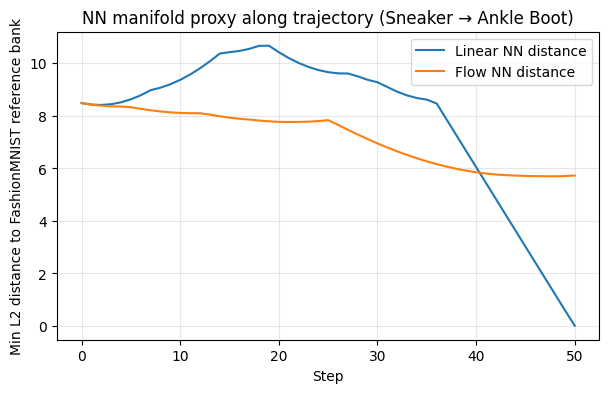

NN manifold-proxy summary
  Linear mean distance: 7.9211
  Flow   mean distance: 7.1757
  Linear max  distance: 10.6727
  Flow   max  distance: 8.4893


In [22]:
@torch.no_grad()
def build_reference_bank(dataset, max_items=5000, seed=42):
    """Build a flat reference bank of real FashionMNIST samples.

    Each image is flattened to a 1D vector. Used to compute nearest-neighbor
    distances as a proxy for how close trajectory states are to data manifold
    """
    n = len(dataset)
    max_items = min(max_items, n)

    # Deterministic random selection for reproducibility
    g = torch.Generator().manual_seed(seed)
    idx = torch.randperm(n, generator=g)[:max_items]

    xs = []
    for i in idx.tolist():
        x_i, _ = dataset[i]
        xs.append(x_i.view(-1))

    return torch.stack(xs, dim=0).float()  # Shape: [max_items, C*H*W]


@torch.no_grad()
def min_l2_distance_to_bank(z, bank_flat):
    """Compute the minimum L2 distance from image z to all samples in the reference bank.

    z:         image tensor of shape [1, C, H, W]
    bank_flat: flattened reference bank of shape [N, D]
    """
    z_flat = z.view(1, -1).detach().cpu().float()
    d = torch.cdist(z_flat, bank_flat, p=2)
    return float(d.min().item())


@torch.no_grad()
def trajectory_nn_curve(trajectory, bank_flat):
    """Compute the NN distance to the reference bank at each step of a trajectory."""
    return [min_l2_distance_to_bank(z_t, bank_flat) for z_t in trajectory]


# Build NN reference bank once and reuse across cells
if "nn_bank_flat" not in globals():
    nn_bank_flat = build_reference_bank(test_dataset, max_items=5000, seed=SEED)
    print("Built NN reference bank with shape:", tuple(nn_bank_flat.shape))
else:
    print("Reusing existing NN reference bank with shape:", tuple(nn_bank_flat.shape))

# Generate trajectories for current example and compute NN distances
steps_nn = 50
linear_traj_nn = linear_interpolation(x_a, x_b, steps=steps_nn + 1)
_, flow_traj_nn = run_flow_trajectory(rf_d2d, x_a, steps=steps_nn, n_vis=9)

linear_nn = trajectory_nn_curve(linear_traj_nn, nn_bank_flat)
flow_nn = trajectory_nn_curve(flow_traj_nn, nn_bank_flat)

t_ax = list(range(len(flow_nn)))
plt.figure(figsize=(7, 4))
plt.plot(t_ax, linear_nn, label="Linear NN distance")
plt.plot(t_ax, flow_nn, label="Flow NN distance")
plt.xlabel("Step")
plt.ylabel("Min L2 distance to FashionMNIST reference bank")
plt.title(
    f"NN manifold proxy along trajectory "
    f"({FMNIST_CLASS_NAMES[SOURCE_CLASS]} → {FMNIST_CLASS_NAMES[TARGET_CLASS]})"
)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Summary statistics
print("NN manifold-proxy summary")
print(f"  Linear mean distance: {float(torch.tensor(linear_nn).mean()):.4f}")
print(f"  Flow   mean distance: {float(torch.tensor(flow_nn).mean()):.4f}")
print(f"  Linear max  distance: {float(torch.tensor(linear_nn).max()):.4f}")
print(f"  Flow   max  distance: {float(torch.tensor(flow_nn).max()):.4f}")

### 5.2 Random-Pair Aggregation

The same NN manifold proxy metric aggregated over many random pairs for more robust conclusions.

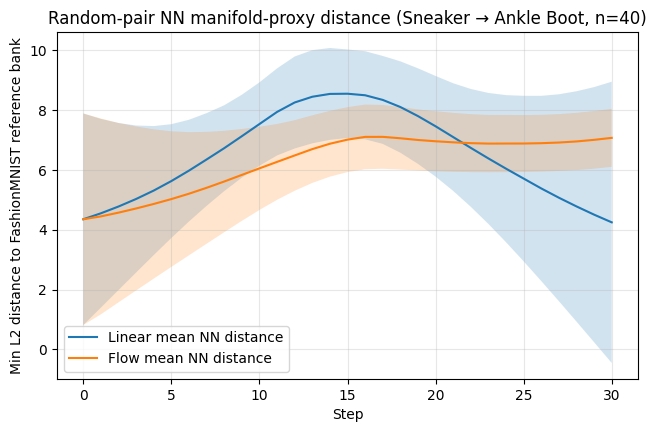

Random-pair NN manifold-proxy summary (Sneaker → Ankle Boot)
  n_pairs: 40
  steps:   30
  Linear mean distance:          6.4922
  Flow   mean distance:          6.2567
  Linear endpoint mean distance: 4.2486
  Flow   endpoint mean distance: 7.0724
  Flow step-advantage fraction:  0.6339


In [23]:
@torch.no_grad()
def evaluate_mapping_nn_distribution(
    flow_model,
    source_label,
    target_label,
    n_pairs=40,
    steps=30,
    bank_flat=None,
):
    """Aggregate NN manifold-proxy distances over n_pairs random unpaired samples.

    For each pair, computes per-step NN distances for both linear + flow
    trajectories. Returns mean/std curves + endpoint statistics
    """
    if bank_flat is None:
        bank_flat = nn_bank_flat  # Use the globally built reference bank

    linear_curves = []
    flow_curves = []

    for _ in range(n_pairs):
        # Sample an independent random source and target image
        idx_a = random.choice(test_label_index[source_label])
        idx_b = random.choice(test_label_index[target_label])

        x_a_local, _ = test_dataset[idx_a]
        x_b_local, _ = test_dataset[idx_b]

        x_a_local = x_a_local.unsqueeze(0).to(device)
        x_b_local = x_b_local.unsqueeze(0).to(device)

        # Generate both trajectories for this pair
        linear_traj = linear_interpolation(x_a_local, x_b_local, steps=steps + 1)
        _, flow_traj = run_flow_trajectory(flow_model, x_a_local, steps=steps, n_vis=9)

        # Compute NN distance at each trajectory step
        linear_curve = torch.tensor(
            trajectory_nn_curve(linear_traj, bank_flat), dtype=torch.float32
        )
        flow_curve = torch.tensor(
            trajectory_nn_curve(flow_traj, bank_flat), dtype=torch.float32
        )

        linear_curves.append(linear_curve)
        flow_curves.append(flow_curve)

    # Stack to [n_pairs, steps+1] for aggregation
    linear_mat = torch.stack(linear_curves, dim=0)
    flow_mat = torch.stack(flow_curves, dim=0)

    # Step advantage: fraction of steps where flow is closer to the manifold than linear
    per_pair_step_adv = (flow_mat < linear_mat).float().mean(dim=1)

    return {
        "source_label": int(source_label),
        "target_label": int(target_label),
        "n_pairs": int(n_pairs),
        "steps": int(steps),
        "linear_mean_curve": linear_mat.mean(dim=0),   # Shape: [steps+1]
        "flow_mean_curve": flow_mat.mean(dim=0),
        "linear_std_curve": linear_mat.std(dim=0),
        "flow_std_curve": flow_mat.std(dim=0),
        "linear_mean_dist": float(linear_mat.mean().item()),
        "flow_mean_dist": float(flow_mat.mean().item()),
        "linear_endpoint_mean_dist": float(linear_mat[:, -1].mean().item()),
        "flow_endpoint_mean_dist": float(flow_mat[:, -1].mean().item()),
        "flow_step_advantage_mean": float(per_pair_step_adv.mean().item()),
    }


nn_result = evaluate_mapping_nn_distribution(
    flow_model=rf_d2d,
    source_label=SOURCE_CLASS,
    target_label=TARGET_CLASS,
    n_pairs=40,
    steps=30,
)

# Plot mean NN distance curves with ±1 std deviation bands
xs = torch.arange(nn_result["steps"] + 1)
lin_mu = nn_result["linear_mean_curve"]
flow_mu = nn_result["flow_mean_curve"]
lin_sd = nn_result["linear_std_curve"]
flow_sd = nn_result["flow_std_curve"]

plt.figure(figsize=(7.5, 4.5))
plt.plot(xs, lin_mu, label="Linear mean NN distance")
plt.fill_between(xs.numpy(), (lin_mu - lin_sd).numpy(), (lin_mu + lin_sd).numpy(), alpha=0.2)
plt.plot(xs, flow_mu, label="Flow mean NN distance")
plt.fill_between(xs.numpy(), (flow_mu - flow_sd).numpy(), (flow_mu + flow_sd).numpy(), alpha=0.2)
plt.xlabel("Step")
plt.ylabel("Min L2 distance to FashionMNIST reference bank")
plt.title(
    f"Random-pair NN manifold-proxy distance "
    f"({FMNIST_CLASS_NAMES[SOURCE_CLASS]} → {FMNIST_CLASS_NAMES[TARGET_CLASS]}, n={nn_result['n_pairs']})"
)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Summary statistics
print(
    f"Random-pair NN manifold-proxy summary "
    f"({FMNIST_CLASS_NAMES[SOURCE_CLASS]} → {FMNIST_CLASS_NAMES[TARGET_CLASS]})"
)
print(f"  n_pairs: {nn_result['n_pairs']}")
print(f"  steps:   {nn_result['steps']}")
print(f"  Linear mean distance:          {nn_result['linear_mean_dist']:.4f}")
print(f"  Flow   mean distance:          {nn_result['flow_mean_dist']:.4f}")
print(f"  Linear endpoint mean distance: {nn_result['linear_endpoint_mean_dist']:.4f}")
print(f"  Flow   endpoint mean distance: {nn_result['flow_endpoint_mean_dist']:.4f}")
print(f"  Flow step-advantage fraction:  {nn_result['flow_step_advantage_mean']:.4f}")

## Setup Overview

- **Data:** FashionMNIST, normalized to $[-1, 1]$, input size $32 \times 32$
- **Task:** Unconditional Data-to-Data Flow Matching (Sneaker → Ankle Boot)
- **Model:** DiT-Llama with `num_classes=1` (no semantic conditioning signal)
- **Training:** Flow Matching on paths $z_t = (1-t)x_A + t\,x_B$ with target $u_t = x_B - x_A$
- **Pairing:** Strictly unpaired random source-target sampling
- **Main reference baseline:** Linear interpolation (useful but endpoint-favored because it uses an explicit target sample)
- **Evaluation:**
  - Semantic trajectory proxy (classifier-based)
  - NN manifold proxy along trajectories (single example + random-pair aggregation)
  - Additional diagnostics (qualitative batch review, endpoint diagnostics, capacity ablation)

## Final Summary

### What was done?

- An unconditional Data-to-Data Flow Matching model was trained on FashionMNIST
- Exactly one source class (Sneaker, 7) and one target class (Ankle Boot, 9)
- The model receives no class label -> only the images themselves
- Main comparison: learned flow vs. linear pixel-space interpolation

### Key Differences from Notebook 04

| Aspect | Notebook 04 (MNIST) | Notebook 05 (FashionMNIST) |
|---|---|---|
| Dataset | MNIST | FashionMNIST |
| Classes | 6 pairs (0→1, 1→7, …) | 1 pair (Sneaker→Ankle Boot) |
| Conditioning | Class-pair ID as condition | None - constant dummy index |
| Checkpoint path | `assets/d2d_runs/` | `assets/fmnist_d2d_runs/` |

### Open Questions

- Does the unconditional model learn structured transport despite the missing signal?
- Is the transition easier or harder for visually similar classes (both footwear)?
- How do results change when visually dissimilar classes are chosen?

## Quick Evaluation + Interpretation

- **Training behavior:** Loss curves are stable and train/val stay close, which suggests the model learns a non-trivial mapping signal.
- **Semantic trajectory signal:** In many examples, target confidence increases along the flow path, but this is not perfectly consistent across all sampled pairs.
- **Endpoint caveat:** Linear interpolation is strong on endpoint metrics because it explicitly uses a real target image at $t=1$. So endpoint-only comparisons likely overestimate linear as a general path baseline.
- **Path-quality signal:** On NN manifold diagnostics, flow often looks competitive (and sometimes better) over intermediate steps, even when endpoint numbers are weaker.

### Interpretation (current state)

These results are **promising but still preliminary**. The model appears capable of learning structured transitions in the unconditional setting, but the evidence is not yet strong enough for a robust claim of semantically meaningful interpolation across settings.

A cleaner next step is to separate **non-oracle baselines** (e.g., identity/global shift) from **oracle references** (linear with explicit target) and prioritize path-level metrics over endpoint-only metrics.